In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, pearsonr, probplot

df = pd.read_csv("amz_uk_price_prediction_dataset.csv")

df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape: (2443651, 9)

Columns:
['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller', 'boughtInLastMonth', 'category']

Data types:
uid                    int64
asin                     str
title                    str
stars                float64
reviews                int64
price                float64
isBestSeller            bool
boughtInLastMonth      int64
category                 str
dtype: object


In [3]:
best_seller_crosstab = pd.crosstab(
    df["category"],
    df["isBestSeller"]
)

best_seller_crosstab

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [4]:
best_seller_crosstab.columns = ["Not Best Seller", "Best Seller"]

best_seller_crosstab

,Not Best Seller,Best Seller
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [5]:
best_seller_proportion = (
    df.groupby("category")["isBestSeller"]
      .mean()
      .sort_values(ascending=False)
)

best_seller_proportion.head(20)

category
Grocery                           0.058135
Smart Home Security & Lighting    0.057692
Health & Personal Care            0.057686
Mobile Phone Accessories          0.042471
Power & Hand Tools                0.035339
Billiard, Snooker & Pool          0.032129
Pet Supplies                      0.030200
Home Brewing & Wine Making        0.028455
Wind Instruments                  0.028000
Mirrors                           0.028000
Professional Medical Supplies     0.027344
PC & Video Games                  0.025466
Bakeware                          0.025105
Material Handling Products        0.025000
Bedding Accessories               0.024390
Tableware                         0.024096
Arts & Crafts                     0.024086
Baby                              0.022658
Lighting                          0.022556
Window Treatments                 0.020921
Name: isBestSeller, dtype: float64

In [6]:
best_seller_percentage = (
    best_seller_proportion * 100
).sort_values(ascending=False)

best_seller_percentage.head(20)

category
Grocery                           5.813467
Smart Home Security & Lighting    5.769231
Health & Personal Care            5.768628
Mobile Phone Accessories          4.247104
Power & Hand Tools                3.533895
Billiard, Snooker & Pool          3.212851
Pet Supplies                      3.020028
Home Brewing & Wine Making        2.845528
Wind Instruments                  2.800000
Mirrors                           2.800000
Professional Medical Supplies     2.734375
PC & Video Games                  2.546634
Bakeware                          2.510460
Material Handling Products        2.500000
Bedding Accessories               2.439024
Tableware                         2.409639
Arts & Crafts                     2.408629
Baby                              2.265781
Lighting                          2.255639
Window Treatments                 2.092050
Name: isBestSeller, dtype: float64

In [7]:
chi2_table = pd.crosstab(
    df["category"],
    df["isBestSeller"]
)

chi2, p_value, degrees_of_freedom, expected = chi2_contingency(chi2_table)

print("Chi-square statistic:", chi2)
print("Degrees of freedom:", degrees_of_freedom)
print("p-value:", p_value)

Chi-square statistic: 36540.20270061387
Degrees of freedom: 295
p-value: 0.0


In [8]:
n = chi2_table.to_numpy().sum()

rows, columns = chi2_table.shape

cramers_v = np.sqrt(
    (chi2 / n) / min(rows - 1, columns - 1)
)

print("Cramér's V:", cramers_v)

Cramér's V: 0.1222829439760564


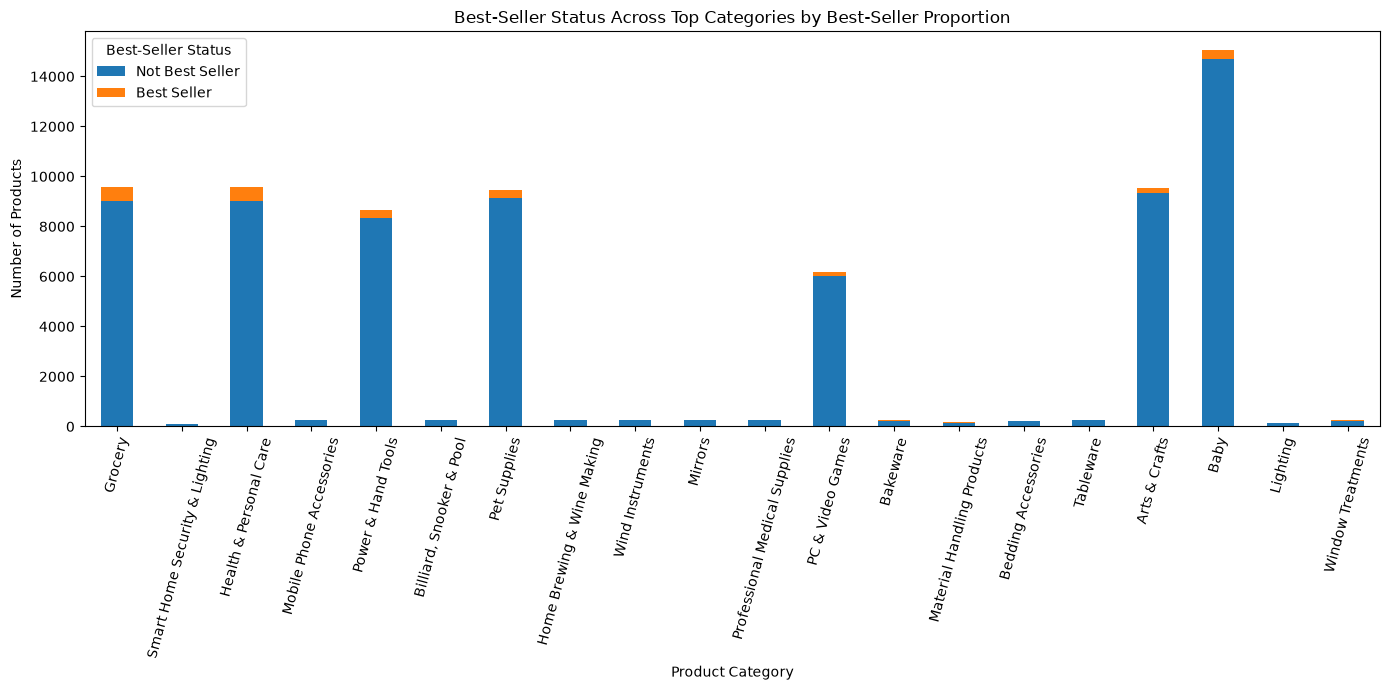

In [9]:
top_categories = best_seller_percentage.head(20).index

plot_data = best_seller_crosstab.loc[top_categories]

plot_data.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7)
)

plt.xlabel("Product Category")
plt.ylabel("Number of Products")
plt.title("Best-Seller Status Across Top Categories by Best-Seller Proportion")
plt.xticks(rotation=75)
plt.legend(title="Best-Seller Status")
plt.tight_layout()
plt.show()

In [10]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 9.99
Q3: 45.99
IQR: 36.0
Lower bound: -44.01
Upper bound: 99.99000000000001


In [11]:
df_clean = df[
    (df["price"] >= lower_bound) &
    (df["price"] <= upper_bound)
].copy()

print("Original rows:", len(df))
print("Rows after removing outliers:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))
print(
    "Percentage removed:",
    (len(df) - len(df_clean)) / len(df) * 100
)

Original rows: 2443651
Rows after removing outliers: 2115963
Rows removed: 327688
Percentage removed: 13.409770871536075


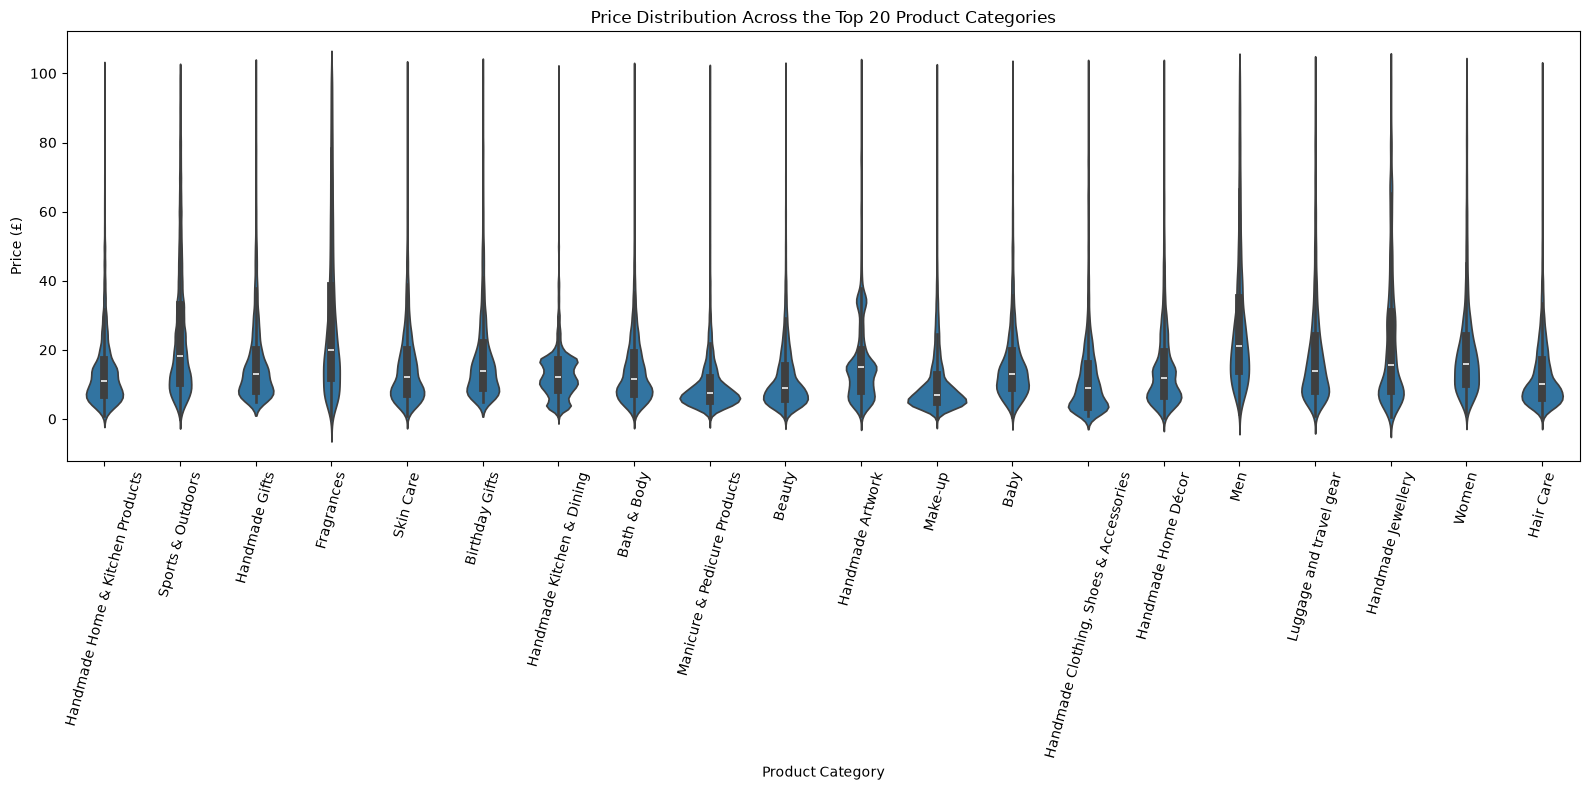

In [12]:
top_20_categories = (
    df_clean["category"]
    .value_counts()
    .head(20)
    .index
)

df_top20 = df_clean[
    df_clean["category"].isin(top_20_categories)
]

plt.figure(figsize=(16, 8))

sns.violinplot(
    data=df_top20,
    x="category",
    y="price"
)

plt.xlabel("Product Category")
plt.ylabel("Price (£)")
plt.title("Price Distribution Across the Top 20 Product Categories")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [13]:
median_price_by_category = (
    df_clean.groupby("category")["price"]
    .median()
    .sort_values(ascending=False)
)

median_price_by_category.head(10)

category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64

In [14]:
top_10_categories = (
    df_clean["category"]
    .value_counts()
    .head(10)
)

top_10_categories

category
Sports & Outdoors                         694092
Beauty                                     19233
Bath & Body                                19050
Manicure & Pedicure Products               18904
Handmade Clothing, Shoes & Accessories     18811
Make-up                                    18718
Skin Care                                  18686
Hair Care                                  18625
Birthday Gifts                             18398
Handmade Gifts                             17948
Name: count, dtype: int64

In [15]:
average_price_top10 = (
    df_clean[
        df_clean["category"].isin(top_10_categories.index)
    ]
    .groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

average_price_top10

category
Sports & Outdoors                         25.172065
Birthday Gifts                            18.600195
Handmade Gifts                            17.395112
Skin Care                                 15.654722
Bath & Body                               14.678683
Hair Care                                 13.461408
Handmade Clothing, Shoes & Accessories    12.958639
Beauty                                    12.523480
Make-up                                   10.612918
Manicure & Pedicure Products              10.231825
Name: price, dtype: float64

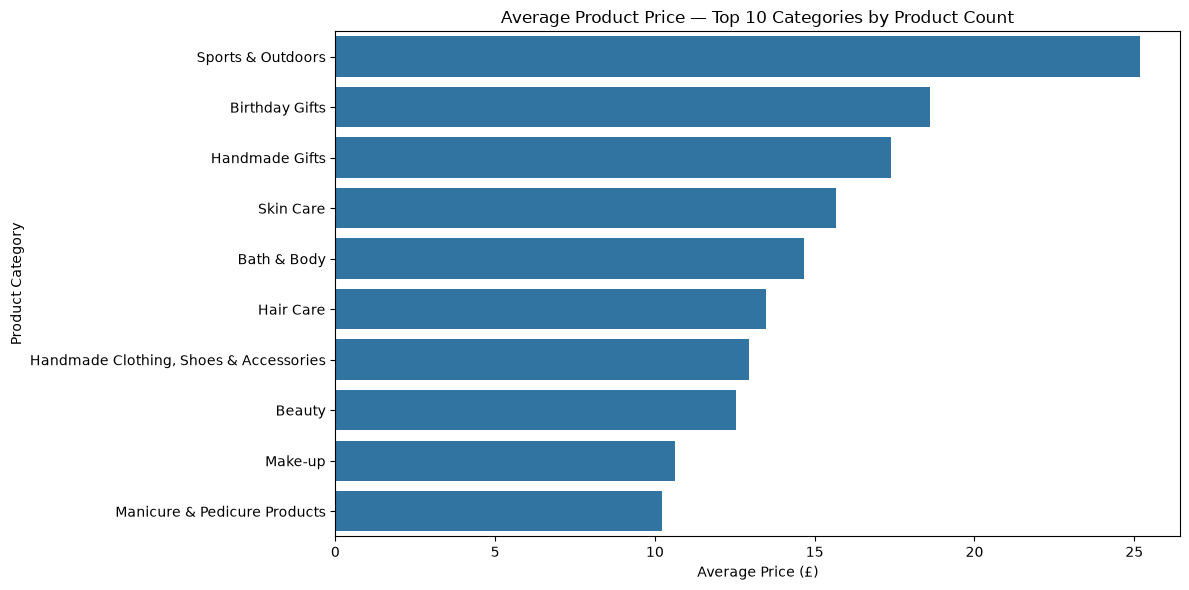

In [16]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=average_price_top10.values,
    y=average_price_top10.index
)

plt.xlabel("Average Price (£)")
plt.ylabel("Product Category")
plt.title("Average Product Price — Top 10 Categories by Product Count")
plt.tight_layout()
plt.show()

In [17]:
average_price_by_category = (
    df_clean.groupby("category")["price"]
    .mean()
    .sort_values(ascending=False)
)

average_price_by_category.head(10)

category
Motherboards         68.772432
Boxing Shoes         67.417803
Desktop PCs          66.915562
Tablets              66.552971
Graphics Cards       65.103509
Digital Frames       60.745129
Streaming Clients    60.241803
Hockey Shoes         60.094796
Computer Cases       58.339884
Skiing Poles         57.867770
Name: price, dtype: float64

In [18]:
top_10_rating_categories = (
    df_clean["category"]
    .value_counts()
    .head(10)
    .index
)

df_rating_top10 = df_clean[
    df_clean["category"].isin(top_10_rating_categories)
]

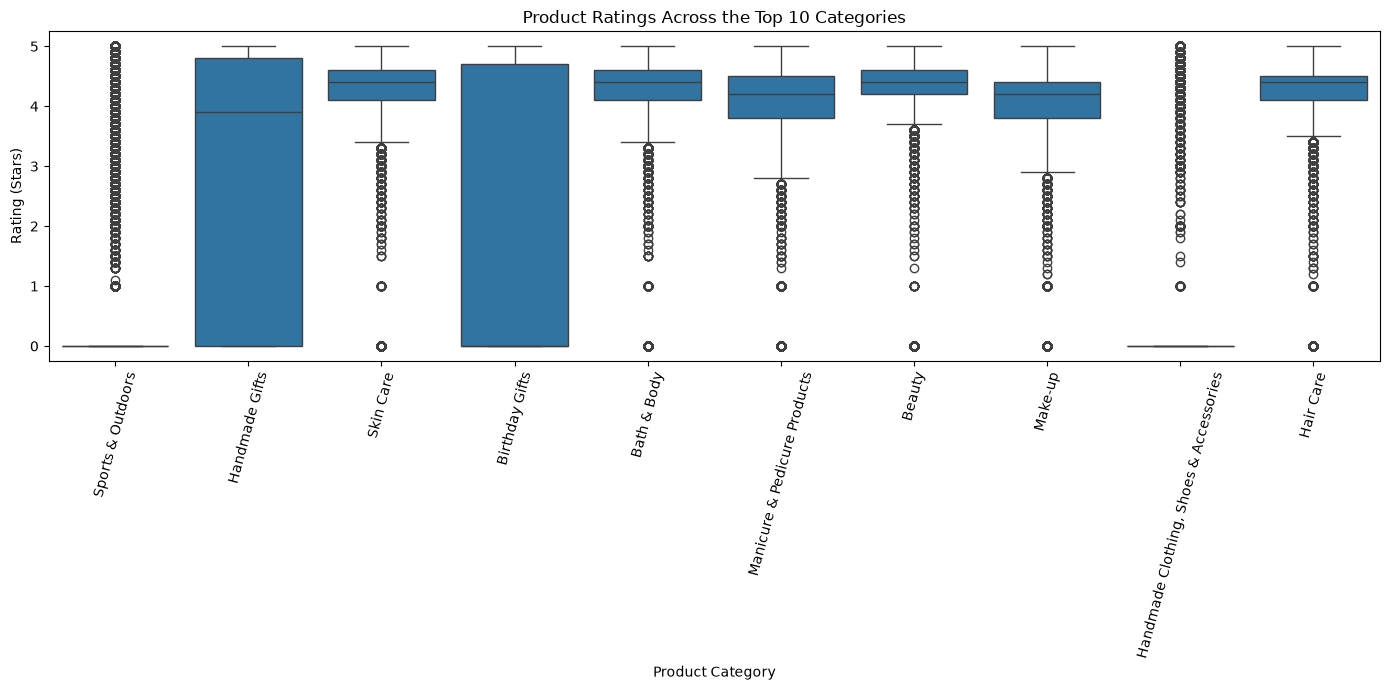

In [19]:
plt.figure(figsize=(14, 7))

sns.boxplot(
    data=df_rating_top10,
    x="category",
    y="stars"
)

plt.xlabel("Product Category")
plt.ylabel("Rating (Stars)")
plt.title("Product Ratings Across the Top 10 Categories")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

In [20]:
median_rating_by_category = (
    df_clean.groupby("category")["stars"]
    .median()
    .sort_values(ascending=False)
)

median_rating_by_category.head(10)

category
Computer Memory                 4.7
Building & Construction Toys    4.6
Office Paper Products           4.6
Luxury Food & Drink             4.6
Kids' Play Figures              4.6
Hobbies                         4.6
Beer, Wine & Spirits            4.6
Laptop Accessories              4.6
Cables & Accessories            4.5
CPUs                            4.5
Name: stars, dtype: float64

In [21]:
price_rating_corr = df_clean[
    ["price", "stars"]
].corr()

price_rating_corr

,price,stars
price,1.000000,-0.077673
stars,-0.077673,1.000000


In [32]:
correlation = df_clean["price"].corr(df_clean["stars"])

print("Correlation between price and rating:", correlation)

Correlation between price and rating: -0.0776729987818131


In [22]:
price_stars = df_clean[["price", "stars"]].dropna()

r, p_value = pearsonr(
    price_stars["price"],
    price_stars["stars"]
)

print("Pearson correlation:", r)
print("p-value:", p_value)

Pearson correlation: -0.07767299878181345
p-value: 0.0


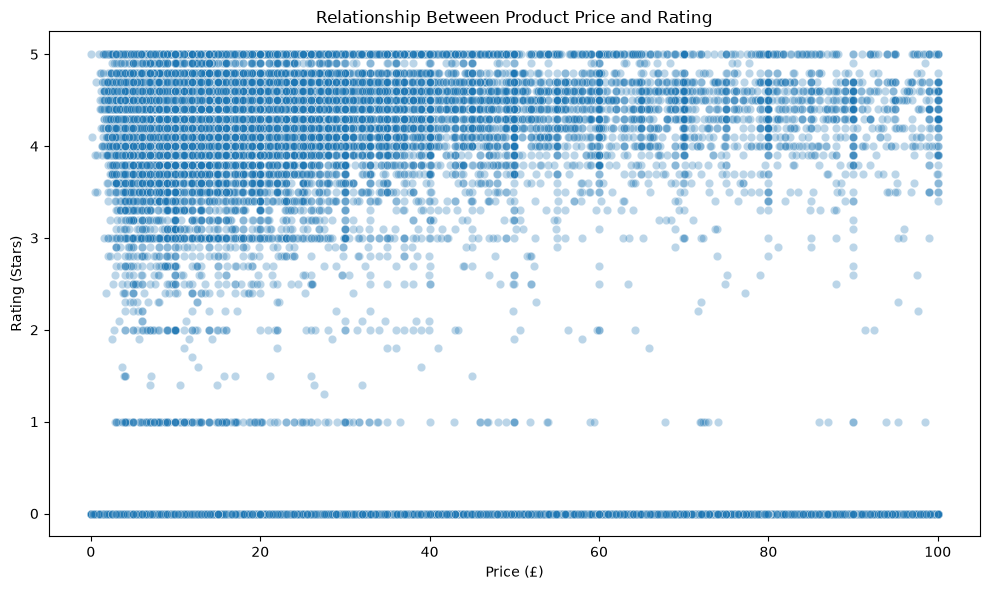

In [23]:
plot_sample = df_clean.sample(
    n=50000,
    random_state=42
)

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_sample,
    x="price",
    y="stars",
    alpha=0.3
)

plt.xlabel("Price (£)")
plt.ylabel("Rating (Stars)")
plt.title("Relationship Between Product Price and Rating")
plt.tight_layout()
plt.show()

In [24]:
numerical_columns = [
    "stars",
    "reviews",
    "price",
    "boughtInLastMonth"
]

correlation_matrix = df_clean[numerical_columns].corr()

correlation_matrix

,stars,reviews,price,boughtInLastMonth
stars,1.000000,0.083920,-0.077673,0.113994
reviews,0.083920,1.000000,-0.008498,0.105624
price,-0.077673,-0.008498,1.000000,-0.059051
boughtInLastMonth,0.113994,0.105624,-0.059051,1.000000


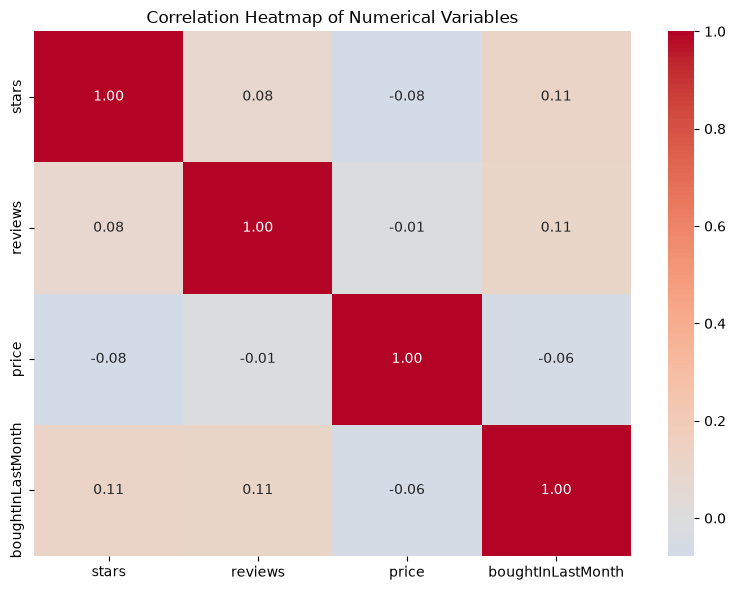

In [25]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Variables")
plt.tight_layout()
plt.show()

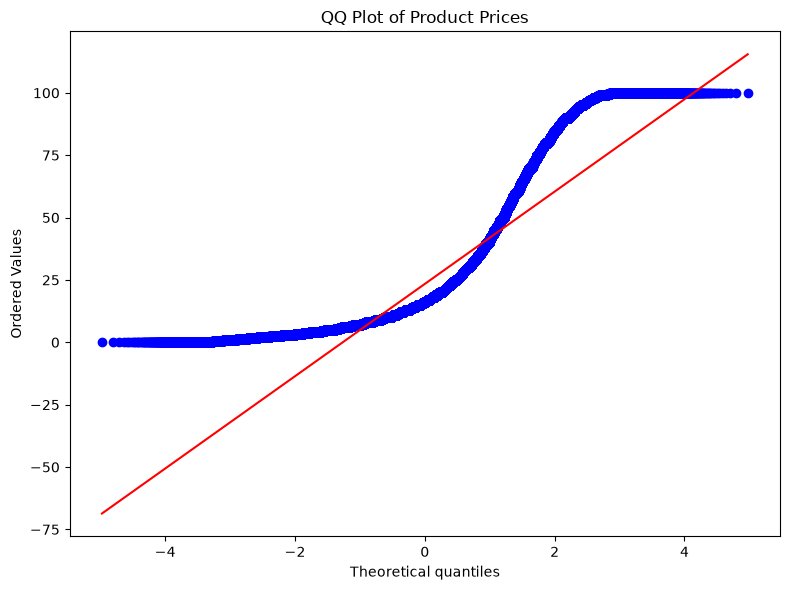

In [26]:
plt.figure(figsize=(8, 6))

probplot(
    df_clean["price"],
    dist="norm",
    plot=plt
)

plt.title("QQ Plot of Product Prices")
plt.tight_layout()
plt.show()

In [27]:
print("Price skewness:", df_clean["price"].skew())
print("Price kurtosis:", df_clean["price"].kurt())

Price skewness: 1.6383204687806214
Price kurtosis: 2.2892840204129103


In [28]:
print(df["price"].describe())

count    2.443651e+06
mean     8.924381e+01
std      3.456089e+02
min      0.000000e+00
25%      9.990000e+00
50%      1.909000e+01
75%      4.599000e+01
max      1.000000e+05
Name: price, dtype: float64


In [29]:
print("Skewness:", df["price"].skew())
print("Kurtosis:", df["price"].kurt())

Skewness: 27.49297756628037
Kurtosis: 4241.616412866521


In [30]:
raw_correlation = df["price"].corr(df["stars"])

print("Correlation between price and stars:", raw_correlation)

Correlation between price and stars: -0.12490673262148537


In [31]:
raw_median_price = (
    df.groupby("category")["price"]
    .median()
    .sort_values(ascending=False)
)

clean_median_price = (
    df_clean.groupby("category")["price"]
    .median()
    .sort_values(ascending=False)
)

print("Raw data:")
print(raw_median_price.head(10))

print("\nAfter removing outliers:")
print(clean_median_price.head(10))

Raw data:
category
Laptops                                1042.725
Desktop PCs                             810.400
Snowboards                              366.725
Home Audio Record Players               326.080
3D Printers                             319.000
Motorbike Exhaust & Exhaust Systems     313.830
Graphics Cards                          259.980
Snowboard Boots                         258.990
Lenses                                  249.990
Barebone PCs                            244.990
Name: price, dtype: float64

After removing outliers:
category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64


Key Findings
1. Best-seller status varies by category.
The proportion of products classified as best-sellers differs substantially across product categories. Grocery had the highest observed proportion at approximately 5.81%. A chi-square test produced a very small p-value, indicating that best-seller status and category are statistically associated. However, Cramér's V was approximately 0.122, indicating that the strength of this association is relatively modest.
2. Product prices are strongly affected by extreme observations.
The original dataset contains prices ranging from £0 to £100,000. Using the IQR method, prices above approximately £99.99 were treated as outliers, removing approximately 13.4% of the observations. Removing these extreme values produces a much more representative picture of typical product prices.

3. Desktop PCs have the highest median price after outlier removal.
Across all categories, Desktop PCs had the highest median price at approximately £74.00. Motherboards had the highest average price at approximately £68.77. The difference between these results shows why both mean and median can be useful when comparing product categories.

4. Ratings are generally high across categories.
Computer Memory had the highest median rating at 4.7 stars. Several other categories had median ratings of 4.6. Overall, ratings show considerably less variation than prices.

5. Price and rating have only a weak relationship.
The Pearson correlation between price and stars after removing price outliers was approximately −0.078. This indicates a very weak negative relationship. Therefore, higher-priced products do not generally receive substantially higher customer ratings.

6. Product prices are not normally distributed.
The QQ plot shows substantial deviations from normality. Even after removing outliers, price has a positive skewness of approximately 1.64. Without outlier removal, skewness increases dramatically to approximately 27.49.

7. Outlier removal materially changes the business interpretation.
The raw data contain extremely expensive products that substantially increase the mean, standard deviation, skewness and kurtosis. For example, the raw mean price is approximately £89.24 while the median is only £19.09. This large difference demonstrates the influence of extreme prices.

Overall business insight
The analysis suggests that product category is more informative for understanding best-seller status and typical pricing than product rating is for predicting price. Pricing strategies should therefore consider category-specific price distributions rather than relying on a single overall Amazon-wide average. At the same time, extreme prices should be investigated separately rather than automatically discarded in a real business setting, because they may represent legitimate premium products rather than data errors.
